**设想一下。** 你打开东方财富，自选股资讯里弹出一条：

> [!info] 截至x年x月x日收市，公司控股股东、董事长xxx先生通过上海证券交易所股票交易系统以集中竞价交易方式累计增持公司股份xx股，约占公司总股本的y%，增持金额为人民币z万元，本次增持计划已实施完毕。*

你的第一反应会是什么？ —— 多数人会立刻打开行情软件看一眼，然后问："**我该不该跟？**"

这就是我们今天要研究的因子。

> [!tip] 内部人公开披露的交易，能让外部跟随者赚到钱吗？
> 学术语言：拥有信息优势的控制权人依法申报买入之后，外部投资者按**公开信息**、扣除交易成本后，能否获得显著为正的风险调整收益？

## 内幕交易，局外人能否利用

内幕交易是指公司内部人利用公众无法获取的信息在股市中牟利。James D. Logan 案是一个典型的内幕交易案例。Logan 是 MicroTouch Systems 的董事长，在公司与 Tyco 和 3M 进行秘密收购谈判期间，他于 2000 年 5 月、6 月和 9 月通过一个为未成年子女设立的信托，分十次买入了 14,000 股 MicroTouch 股票。2000 年 11 月 13 日，MicroTouch 宣布被 3M 以每股 21 美元收购，信托卖出股票获利 177,375 美元，不到 6 个月，回报达 152%。

---

正是为了打击内幕交易，SEC 在 1934 年立法，要求强制披露和短线利润归入。所谓短线利润归入，就是指内部人在6个月内买入又卖出（或者卖出又买入）的利润，必须归还公司。

这条规则，加上强制披露，就基本堵死了内幕交易的操作空间。强制披露是什么意思呢，它就是董事、高管、持股超过10%的受益所有人，必须在持股变动后的两个工作日内，通过 Form 4表格进行申报。

所以，高管可以根据自己掌握的内幕消息进行交易 -- 这似乎是无法避免的 -- 但是，公众将在两个工作日之后即可获得同样的信息，但他们有足够的自由先于高管进行交易。高管拥有信息优先权，而公众则拥有先手权。这样就对所有人都公平了。

所以，前面所说的『内幕交易』，只要按规定执行，就变成了合法的内部人交易。

基于『内部人』交易信息，一般公众是否可以从中获得某种 Alpha? 最近 quantinsti 上发表了一篇博文对此进行了研究。在国内也有类似的披露制度，相关信息也能通过 tushare 获得，所以，本文就来研究下这个 Alpha。

文章分两部分。第一部分是 SEC Form 4内幕买入，适用于美股；第二部分则是对 A 股内部人交易信息披露的 Alpha 的研究。

> [!info]
> 2026 年 8 月，AlphaAI 创始人 **Mikhail Makeev** 用 SEC 免费公开的 EDGAR 数据，对 **2022Q1~2026Q2** 期间全部 C-suite 内幕买入做了一次严格的事件研究——*[SEC Form 4 Insider Purchases in Python: A Filing-Date Event Study with Free EDGAR Data](https://blog.quantinsti.com/sec-form-4-insider-trading-python-event-study/)*（QuantInsti, 2026-08）。本文受该文启发进行了本土化研究。受数据所限，本文的价值在于展现一种严谨的研究方法，而不在于直接提供可复用的因子/策略。

## 一、什么是 SEC Form 4 内部人买入

为了防止内幕交易，美国《1934 年证券交易法》Section 16 要求三类"内部人"披露持股变动：

- 公司的**董事（director）**
- **高管（officer）**，主要指 C-suite
- 持有注册权益证券类别 **10% 以上**的受益所有人

每次发生"受益所有权的变化"，这些人都必须通过 EDGAR 提交 **Form 4**：内部人持股变动报表。

**申报人必须在可报告交易发生后的第二个工作日内完成申报**。这个 deadline 使 Form 4 成为**对做市和量化研究极其便利**的数据：公开、结构化、且披露延迟很短。

### Form 4 的交易代码

Form 4 的非衍生品交易表中，有一个关键字段"交易代码"（transaction code），在原文中，只使用了代码为**P**的记录，对其它进行了排除，原因如下：

| 代码       | SEC 含义（节选）                                                | 原文的处理         |
| ---------- | --------------------------------------------------------------- | ------------------ |
| **P**      | 公开市场买入 **或** 私下买入（Open-market or private purchase） | ✅ 使用             |
| S          | 公开市场卖出或私下卖出                                          | ❌ 排除             |
| A          | 16b-3(d) 项下的授予/奖励等                                      | ❌ 排除             |
| M          | 衍生品的行权/转换                                               | ❌ 排除             |
| F          | 为支付行权价或税负交付/扣留的证券                               | ❌ 排除             |
| G          | 善意赠与                                                        | ❌ 排除             |
| C/D/J/X 等 | 转换、发行方处置、"其他"、行权等                                | ❌ 排除（买入研究） |

为什么对卖出记录进行了排除？如果高管和大股东在抛售股票了，难道股票不应该下跌吗？如果把买入和卖出结合使用，按理说这个因子的效果不应该更好吗？

这里我们先做一个理论上的解释，在后面我们还会以大 A 为样本，完成实证研究。实证研究的结果不但能回答这个问题，并且还将有力地说明，凭感觉的主观交易，为什么必然败给量化交易。

对普通投资者而言，我们卖出常常是因为不看好个股前景。但高管卖出股票的原因中，经常混杂多样化、流动性需求、税务规划等与公司前景无关的动机；买入（尤其高管真金白银增持）更可能押注"股价低于价值"。Cohen/Malloy/Pomorski (2012) 曾精细地把交易分为机会型/例行型，进一步确认买入更能区分信息驱动。

当我们把自身的经验投射到其它人身上，从而以自己的经验来解释他人的行为时，就必然得出只要高管卖出，那么公司前景看淡，股份必然下跌的片面结论。

排除片面的主观经验，还原客观真相，这正是量化分析的优势所在。

### 原文的核心结果

原文样本：2022Q1~2026Q2 期间，C-suite、Code P、非 10b5-1 申报的买入，经过过滤后得到 **7,405 个可计分信号**（issuer × 申报日）。用 SPY 做基准的**申报日事件研究**：

| 指标                       | N     | 均值        | 双向聚类 t    |
| -------------------------- | ----- | ----------- | ------------- |
| SPY 调整 CAR（1 个交易日） | 7,405 | **+0.534%** | 6.460         |
| SPY 调整 CAR（5 个交易日） | 7,404 | **+1.009%** | 5.053         |
| CAR（21 交易日）           | 7,397 | +0.980%     | 1.678（含 0） |
| CAR（63 交易日）           | 7,048 | +1.103%     | 1.194（含 0） |

结论措辞非常小心，但实际上因子的 Alpha 效应很显著：

1. **短期（1 日 +0.53%、5 日 +1.01%）有统计显著的 SPY 调整超额收益**，双向聚类 t 在 6.46 / 5.05，置信区间不含 0。
2. **更长期限（21/63 日）的 CAR/BHAR 置信区间包含 0**——没有稳定证据表明内幕买入后存在持久的漂移。

## 二、A 股 F4

A 股虽然没有 Form 4，但也有同一性质的制度：**董监高及持股 5% 以上股东（大股东）的股份变动必须披露**。

这里我们汇总一下各本文提及的三处证券市场中，如何获取内部人交易披露信息：

| 国家/地区 | 平台                                                       | 法律基础                    | 主体                              |
| --------- | ---------------------------------------------------------- | --------------------------- | --------------------------------- |
| 美国      | **EDGAR**（SEC 运营）                                      | 1934 年《证券法》Section 16 | 董事/高管/>10% 受益所有人，Form 4 |
| 港股      | **HKEXnews 披露易**                                        | SFO 第 XV 部                | 董事/最高行政人员/5% 大股东       |
| A 股      | **巨潮资讯网**（cninfo.com.cn）+ 上交所/深交所信息披露平台 | 《证券法》+ 沪深规则        | 董监高 + 5% 以上股东              |

三者都是**法定公开的免费电子化披露**。

但在 A 股，法定渠道公开的数据是以文本方式披露的，直接使用的话，我们需要进行数据抓取和解析。因此，我们一般是通过第三方软件，比如通过 Tushare 来获取内部人交易信息。

## Tushare 的对应数据接口

Tushare（需要一定积分）提供了**已结构化的董监高/股东增减持数据**：

1. **`stk_holdertrade`（股东增减持）** —— 最接近 Form 4 的接口，它返回的数据包含以下字段：
   - `ann_date`：公告日期
   - `holder_name`：股东/高管姓名
   - `holder_type`：**G=高管（董监高）、P=个人股东（5% 以上）、C=公司股东**
   - `in_de`：**IN=增持，DE=减持**（对应 Form 4 的 P（买）/S（卖））
   - `change_vol`、`change_ratio`：变动数量、比例
   - `avg_price`、`after_share`、`after_ratio`：平均成交价、变动后持股
   - `total_share`
   - `begin_date`: 增持开始之日
   - `end_date`: 增持结束之日

2. `stk_managers`（董监高名单）、`top10_holders`（前十大股东）可作为补充对齐工具。

先取数据并缓存（避免每次调试都调 Tushare）：

<!--PAID CONTENT START-->

In [1]:
from pathlib import Path
import tempfile
import pandas as pd
import numpy as np

import tushare as ts

pro = ts.pro_api()

# cell 2：数据获取 + 缓存（stk_holdertrade 单次调用上限 3000 行，必须分片）
# ---- 数据跨度开关（调试用）----
# SAMPLE_YEARS = 0   → 用全部近 FULL_YEARS(7) 年（正式结论）
# SAMPLE_YEARS = 1   → 只用最近 1 年（调试跑通逻辑，快）
# 调通后把 SAMPLE_YEARS 设回 0 即可跑全量。
FULL_YEARS = 7
SAMPLE_YEARS = 0   # ← 正式：0（7 年全量）；调试可改 1（仅 1 年，速跑通）

YEARS = FULL_YEARS if SAMPLE_YEARS == 0 else SAMPLE_YEARS
END_DATE = pd.Timestamp.today().strftime("%Y%m%d")
START_DATE = (pd.Timestamp.today() - pd.DateOffset(years=YEARS)).strftime("%Y%m%d")

# 缓存目录：使用系统临时目录，保证任何环境（无需 .runtime）都能直接运行
def runtime_dir():
    return Path(tempfile.gettempdir()) / "sec-form4-insider-purchases"

RUNTIME_DIR = runtime_dir()
RUNTIME_DIR.mkdir(parents=True, exist_ok=True)
CACHE = RUNTIME_DIR / f"holder_data_{YEARS}y.parquet"   # 缓存按年份命名，避免调试/正式误用
print(f"缓存目录：{RUNTIME_DIR}")
print(f"数据范围：{START_DATE} ~ {END_DATE}（{'近 7 年' if SAMPLE_YEARS == 0 else f'调试模式：仅 {YEARS} 年'}）")

缓存目录：/var/folders/b5/73vzvtdn4pn_8wt6rpd2tb_w0000gn/T/sec-form4-insider-purchases
数据范围：20190908 ~ 20260908（近 7 年）


<!--PAID CONTENT END-->

通过以下方法，获取 tushare 数据并利用缓存。


In [2]:
# cell 2b：数据获取（含 begin_date/close_date 字段，用于披露滞后判断）
# 调试开关：DEBUG_YEARS=1 只拉 1 年（快）；=0 用 cell 2 的 SAMPLE_YEARS 决定（正式 7 年）
DEBUG_YEARS = 0  # ← 正式：0（7 年全量）；调试：1（1 年）
_EFFECTIVE_YEARS = DEBUG_YEARS if DEBUG_YEARS else YEARS
_CACHE = RUNTIME_DIR / f"holder_data_{_EFFECTIVE_YEARS}y_v2.parquet"  # v2: 含 begin/close 字段

def fetch_holdertrade_all(start=None, end=None, chunk="3M"):
    start = start or (pd.Timestamp.today() - pd.DateOffset(years=_EFFECTIVE_YEARS)).strftime("%Y%m%d")
    end = end or pd.Timestamp.today().strftime("%Y%m%d")
    if _CACHE.exists():
        df = pd.read_parquet(_CACHE)
        if "close_date" in df.columns:  # 字段齐全才复用，否则重拉
            return df
    # 按季度分片，绕过单次 3000 行上限；显式请求 begin_date/close_date（默认不返回）
    fields = "ts_code,ann_date,holder_name,holder_type,in_de,change_vol,change_ratio,after_share,after_ratio,avg_price,total_share,begin_date,close_date"
    idx = pd.date_range(start, end, freq=chunk).strftime("%Y%m%d").tolist()
    idx.append(end)
    frames = []
    for a, b in zip(idx, idx[1:]):
        df = pro.stk_holdertrade(start_date=a, end_date=b, fields=fields)
        if df is not None and not df.empty:
            frames.append(df)
    out = pd.concat(frames).drop_duplicates()
    out.to_parquet(_CACHE)
    return out

raw = fetch_holdertrade_all()
print(f"原始记录：{len(raw)} 行（调试 {_EFFECTIVE_YEARS} 年，v2 含 begin/close 字段）")
print("字段含 begin_date/close_date:", "begin_date" in raw.columns and "close_date" in raw.columns)

/var/folders/b5/73vzvtdn4pn_8wt6rpd2tb_w0000gn/T/ipykernel_96678/1833858645.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(start, end, freq=chunk).strftime("%Y%m%d").tolist()


原始记录：68087 行（调试 7 年，v2 含 begin/close 字段）
字段含 begin_date/close_date: True


通过上述代码，我们把 [STAR_DATE, END_DATE] 区间的所有增减持记录获取下来，保存为 parquet 文件，存放在`CACHE`指定的文件中。

在构造信号量之前，我们要对现有的数据进行分布研究，以完全了解 tushare 每个字段的含义，特别是与时间相关的几个字段。实际上，我们需要考察4个时间：

1. 增持开始时间，在 tushare中是 begin_date
2. 增持结束时间, 在 tushare 中是 close_date
3. 增持结束后的公告时间，在 tushare 中是 ann_date
4. 上述公告在 tushare 中可查阅时间。tushare 未提供它的编制时间。

通过数据分析，我们得到：

1. ann_date < begin_date：0.0%， 所以，tushare数据中，没有在公司发布增持计划时收集信息。
2. ann_date 在 [begin, close] 区间内：6.5% -- 这是不合理的情况，可能反映了数据质量不是特别好。
3. ann_date > close_date：93.5%，这是完成后的公告。

如果我们继续拆解 ann_date > close_date 的分布，我们会发现：

1. ann_date - close_date 的中位数是2天 -- 即公司通常在增持结束后的一1-2个工作日公告；但均值是40天，90%分位是107天，最长的记录超过10年 -- 这或许不是 tushare 的错误。
2. tushare 编录的时间，又会晚于 ann_date 1到3天；但这个数据采样不足，有推测的成份（仅使用了9月8日一天的数据 -- 当时tushare 只编制到上周5，而不是前一个交易日的本周一）

理解这些时间，对我们如何构造买入信号非常重要，甚至对是否有必要购买、采用这些数据都很重要。

鉴于上述数据分布，我们在构造信号时，应该这样处理：

1. 只取 ann_date - close_date <= 2天的记录
2. 从 ann_date($T_0$)次日买入算起，$T_1的收益为$T_{1_{close}}/T_{1_{open}} - 1；此后的收益按$C_n/C_{n-1}-1$计算。

以下代码构造买入信号（全量，不抽样）：

In [3]:
# cell 3：构造"买入信号"（映射 Form 4 漏斗的简化版，保留全部信号）
# 按前文结论：只取 ann_date - close_date <= 2 天的记录 —— 只有这类"增持结束即公告"
# 的信号，其公告日才是"公众首次可见"的时点，才适合做公告日事件研究。
MAX_DISCLOSURE_LAG = 2  # 增持结束(close_date)到公告(ann_date)的最长滞后（自然日）

def build_signals(raw):
    """增持 + 高管/个人/公司股东 → 同一股票×公告日合并为一个信号。
    过滤：ann_date - close_date <= MAX_DISCLOSURE_LAG（排除滞后公告/补录数据）。"""
    if "close_date" not in raw.columns:
        raise ValueError("缺少 close_date 字段，请先运行 cell 2b（需显式请求该字段）")
    s = raw[raw["in_de"] == "IN"].copy()
    # 披露滞后 = 公告日 - 增持结束日
    s["ann_dt"] = pd.to_datetime(s["ann_date"], format="%Y%m%d")
    s["close_dt"] = pd.to_datetime(s["close_date"], format="%Y%m%d", errors="coerce")
    s = s.dropna(subset=["close_dt"])                    # 无 close_date 的记录无法判断时效，排除
    s["disclosure_lag"] = (s["ann_dt"] - s["close_dt"]).dt.days
    s = s[s["disclosure_lag"].between(0, MAX_DISCLOSURE_LAG)]  # 0~2 天：完成后立即公告
    s["value"] = s["change_vol"] * s["avg_price"].fillna(0)
    signals = (s.groupby(["ts_code", "ann_date"], as_index=False)
                .agg(signals_n=("holder_name", "size"),
                     holders=("holder_name", "nunique"),
                     change_vol_sum=("change_vol", "sum"),
                     value_sum=("value", "sum"),
                     holders_type=("holder_type", lambda x: ",".join(sorted(set(x.astype(str))))))
                .rename(columns={"ann_date": "filing_date", "ts_code": "ticker"}))
    return signals

signals = build_signals(raw)
print(f"买入信号数（股票×公告日，滞后≤{MAX_DISCLOSURE_LAG}天，全量）: {len(signals)}")
print(f"涉及股票数: {signals['ticker'].nunique()}")
print(f"信号时间跨度: {signals['filing_date'].min()} ~ {signals['filing_date'].max()}")

买入信号数（股票×公告日，滞后≤2天，全量）: 4747
涉及股票数: 1905
信号时间跨度: 20191127 ~ 20260908


### 实验设计（先读这里，再看代码与结果）

下面的统计表里会出现几个词——**CAR、均值 CAR、pooled t、双向聚类 t、placebo**。逐个说清楚，你才能判断方法对不对：

**① CAR 是什么缩写？**

CAR = **C**umulative **A**bnormal **R**eturn，累计异常收益。

- **"异常收益"（abnormal return）**：单日里，个股收益**超出基准**（这里基准 = 沪深 300）的部分：
  `AR_t = 个股收益_t − 沪深300收益_t`
- **"累计"**：把公告后第 1 天到第 h 天的逐日 AR 累加（复利累乘）：
  `CAR_h = ∏(1 + AR_t) − 1`，t = 1..h

所以 **CAR_1 = 公告后 1 天的累计异常收益**，CAR_21 = 公告后 21 个交易日的累计异常收益，依此类推。

**② "均值 CAR" 是什么？**

一共有 N 个信号（比如 7,092 个增持公告）。每个信号算出一个 `CAR_h`（公告后 h 天的超额表现）。**均值 CAR = 把这 N 个信号的 CAR_h 简单平均**：

`均值 CAR_h = (1/N) × Σ CAR_h,i`

它回答："平均而言，一个增持公告之后 h 天，这批股票相对沪深 300 多跑赢了多少"。注意它是**全信号等权重平均**，不是"你恰好选到某只股票"的条件收益。

**③ pooled t 是什么？**

pooled t 是**把 N 个 CAR 当作互相独立的样本**算的常规 t 检验：

`pooled t = 均值 CAR / (样本标准差 / √N)`

它回答："均值 CAR 距离 0 有几个标准误"——> 4~5 一般就"非常显著"。

**⚠️ 但它有个缺陷**：这假设 N 个信号彼此独立。实际上**同一只股票在 7 年里可能多次增持、同月可能多只股票增持**，这些事件并不独立。pooled t 会把样本量"虚增"，让显著性**被高估**。

**④ 双向聚类 t（two-way clustered t）是什么？**

为了解决 pooled t 的独立性缺陷，用 **Cameron–Gelbach–Miller (CGM) 双向聚类**校正标准误：

- 同时按两个维度聚类：**股票（issuer）** 和 **公告月（entry-month）**
- 同一股票的多次增持、同一月的多只增持，都在聚类内被"合并"成依赖，不当作 N 个独立样本
- 由此算出的标准误更大、显著更保守，t 值通常比 pooled t **更小、更可信**

**表里同时给 pooled t 和双向聚类 t 就是这个原因**：pooled t 是"天真的上界"，双向聚类 t 是"诚实的下界"。两者差距越大，越说明样本内部依赖强。

**⑤ placebo（安慰剂对照组）是什么？**

字面意思就是医学实验里的"安慰剂"——**给真事件配一组"看起来一样但不是这个事件"的对照**。

直接看 CAR 有个陷阱：**CAR 为正，不一定是"公告"造成的，可能是"股票本来就在涨"**（比如高管常在强势期增持，公告时点本身就选了大概率继续涨的日子）。placebo 回答：

> "如果把公告日换成这只股票上另一个【普通日子】，收益还这么大吗？"

做法（代码 cell 7）：
1. 对每个真实信号，在同一只股票的交易日里，**剔除真实公告日 ±63 日窗口**；
2. 在剩下的日子里，**按公告日前 20 日的动量与波动率匹配**，挑出与真实公告日特征最像的一批"假日期"；
3. 用**完全相同的次日开盘入场规则**，把每个假日期当成"事件日"算 CAR；
4. 汇成一张假日期的 CAR **分布**（placebo 面板）。

判读：真实平均 CAR 若**高于 95% 的假日期**，才说明"这个时点"真的特别；若落在分布中间，说明这个收益**换任何普通日子都有**，与公告本身无关。

---

下面 cell 4~7 就是这个设计的实现。cell 4/5 算 CAR，cell 6 算双向聚类 t，cell 7 构建 placebo；cell 8 汇总成最终的统计表和图。

In [4]:
# cell 4：日线数据与事件研究说明
# 关键设计：公告一般是【盘后】发布，外部投资者最早只能【次日开盘】买入。
# 所以事件研究的入场点 = 公告日之后第一个交易日的【开盘价】，
# 第 1 日收益 = 次日 open→close；之后为 close→close。基准做同样处理。
# 这避免了"用当日收盘价"——那是公告出来前就实现不了的收益（lookahead）。
def fetch_daily(ticker, start=None, end=None):
    df = pro.daily(ts_code=ticker, start_date=start or START_DATE, end_date=end or END_DATE)
    if df is None or df.empty:
        return None
    df = df.set_index(pd.to_datetime(df["trade_date"])).sort_index()
    df["open_ret"] = df["open"].pct_change().fillna(0)     # 开盘→收盘
    df["close_ret"] = df["close"].pct_change().fillna(0)   # 收盘→收盘
    return df

def fetch_benchmark(start=None, end=None):
    df = pro.index_daily(ts_code="000300.SH", start_date=start or START_DATE, end_date=end or END_DATE)
    if df is None or df.empty:
        return None
    df = df.set_index(pd.to_datetime(df["trade_date"])).sort_index()
    df["open_ret"] = df["open"].pct_change().fillna(0)
    df["close_ret"] = df["close"].pct_change().fillna(0)
    return df

print("基准：沪深 300（000300.SH）")
print("入场规则：公告日（盘后）→ 次日开盘买入 → 第 1 日 open→close，之后 close→close")

基准：沪深 300（000300.SH）
入场规则：公告日（盘后）→ 次日开盘买入 → 第 1 日 open→close，之后 close→close


In [5]:
# cell 5：事件研究主循环（次日开盘入场，CAR_1/2/3/5/21/63）
def event_study(signals, daily_func, bench_func,
                horizons=(1, 2, 3, 5, 21, 63), start=None, end=None):
    """对每个信号：公告日(盘后)后首个交易日【开盘】进场。
    第 1 日收益 = 次日 open→close（当天持有）；之后 close→close。
    个股与基准各自如此，逐日算超额收益后累乘为 CAR_h = prod(1+x)-1。
    返回逐信号 DataFrame：ticker/filing_date/month + CAR_1..CAR_63。
    """
    bmk = bench_func(start, end)
    if bmk is None:
        return pd.DataFrame()
    bmk = bmk[~bmk.index.duplicated(keep="last")].sort_index()
    rows = []
    for sig in signals.itertuples():
        px = daily_func(sig.ticker, start, end)
        if px is None or px.empty:
            continue
        px = px[~px.index.duplicated(keep="last")].sort_index()
        i0 = px.index.searchsorted(pd.Timestamp(sig.filing_date)) + 1  # 公告后首个交易日
        if i0 + max(horizons) > len(px):
            continue
        # 对齐基准（个股交易日 reindex 到基准）
        bmk_al = bmk[["open", "close"]].reindex(px.index).ffill()
        rec = {"ticker": sig.ticker, "filing_date": str(sig.filing_date)}
        # 第 1 日（i0）：开盘买、收盘卖
        s1 = px["close"].iloc[i0] / px["open"].iloc[i0] - 1
        b1 = bmk_al["close"].iloc[i0] / bmk_al["open"].iloc[i0] - 1
        for h in horizons:
            # 构造前 h 日的超额收益序列
            xs = []
            for t in range(h):
                idx = i0 + t
                if t == 0:
                    xs.append(s1 - b1)
                else:
                    xs.append((px["close"].iloc[idx] / px["close"].iloc[idx - 1] - 1)
                              - (bmk_al["close"].iloc[idx] / bmk_al["close"].iloc[idx - 1] - 1))
            rec[f"CAR_{h}"] = float(np.prod(1.0 + np.array(xs)) - 1.0)
        rows.append(rec)
    out = pd.DataFrame(rows)
    if not out.empty:
        out["month"] = pd.to_datetime(out["filing_date"]).dt.to_period("M").astype(str)
    return out

print("event_study() 已升级：次日开盘入场 + CAR_1/2/3/5/21/63，返回逐信号 CAR 表。")

event_study() 已升级：次日开盘入场 + CAR_1/2/3/5/21/63，返回逐信号 CAR 表。


In [6]:
# cell 6：双向聚类 t（Cameron–Gelbach–Miller）——"股票 × 公告月" 聚类
# 文章"完整复现需要补什么"第 3 点的实现。输入：每个信号一行 CAR + ticker + 公告年月。
def two_way_cluster_t(car_df, y_col, g1_col, g2_col):
    """CGM 最小充分量估计：t = mean / se，se 由 股票 × 公告月 双向聚类给出。"""
    import numpy as np  # 局部 import，保证 cell 独立可运行

    y = car_df[y_col].values
    n = len(y)
    g1 = car_df[g1_col].values       # 股票（issuer）
    g2 = car_df[g2_col].values       # 公告月（entry-month）

    # within-cluster sums for union adjustment
    g1_ids, g1_inv = np.unique(g1, return_inverse=True)
    g2_ids, g2_inv = np.unique(g2, return_inverse=True)

    # depvar residual (demeaned, no regressors -> residual = y - mean)
    res = y - y.mean()

    # meat = sum over clusters of (sum of res in cluster)^2
    def meat(clusters, nids):
        M = np.zeros(nids)
        for i in range(n):
            M[clusters[i]] += res[i]
        return (M ** 2).sum()

    # sandwich: V = (n-1)/(n-2) * [meat_g1/n^2 + meat_g2/n^2 - meat_union/n^2]
    union = (g1.astype(str) + "|" + g2.astype(str))
    _, union_inv = np.unique(union, return_inverse=True)
    meat_g1, meat_g2 = meat(g1_inv, len(g1_ids)), meat(g2_inv, len(g2_ids))
    meat_union = meat(union_inv, len(np.unique(union_inv)))
    n1, n2 = len(g1_ids), len(g2_ids)
    df_adj = min(n1, n2) - 1
    V = (n - 1) / (n - 2) * (meat_g1 + meat_g2 - meat_union) / n ** 2
    se = np.sqrt(V)
    return y.mean() / se if se > 0 else np.nan, df_adj

print("two_way_cluster_t() 就绪：把每个信号的 CAR 与 ticker、公告月拼成 DataFrame 即可用。")

two_way_cluster_t() 就绪：把每个信号的 CAR 与 ticker、公告月拼成 DataFrame 即可用。


In [7]:
# cell 7：placebo 对照（同一 ticker、事件窗口外、匹配动量/波动率的对照日期）
def build_placebo(car_df, daily_years, bmk_daily, horizons=(1, 2, 3, 5, 21),
                  blackout=63, n_placebo=200, seed=42):
    """为每个真实信号构建"假日期"(placebo) 的 CAR，衡量"如果这天不是公告日，收益如何"。
    
    设计（对应原文 §placebo）：
      1. 对每个真实信号，在其同一只股票的【真实公告日 ±63 日之外】的交易日里，
         挑出与公告日前 20 日动量/波动相似的一批候选日；
      2. 以这些假日期为"事件日"，用与真实信号完全相同的次日开盘入场规则算 CAR；
      3. 得到 placebo 面板：dict[horizon -> list[list[float]]]。
    
    解读："真实平均 CAR" 若显著高于 placebo 分布上尾(如 95% 分位)，
    才说明"公告这个时点本身"携带信息；否则正收益更可能来自股票本身
    的动量/波动特征，与公告无关。
    """
    import numpy as np, pandas as pd  # 局部 import

    bmk = bmk_daily
    if bmk is None or bmk.empty:
        return {h: [] for h in horizons}
    bmk = bmk[~bmk.index.duplicated(keep="last")].sort_index()
    bmk_al = bmk[["open", "close"]].reindex  # 后面按个股索引对齐
    rng = np.random.default_rng(seed)
    panels = {h: [] for h in horizons}
    for sig in car_df.itertuples():
        px = daily_years.get(sig.ticker)
        if px is None or px.empty:
            continue
        px = px[~px.index.duplicated(keep="last")].sort_index()
        bmk_px = bmk_al(px.index).ffill()
        i0 = px.index.searchsorted(pd.Timestamp(sig.filing_date))
        cand = [i for i in range(60, len(px) - max(horizons) - 1)
                if abs(i - i0) > blackout]
        def feat(i):
            w = px["close"].pct_change().iloc[max(0, i - 20):i]
            return (w.mean(), w.std())
        target = feat(i0)
        scored = sorted(((abs(feat(i)[0] - target[0]) + abs(feat(i)[1] - target[1]), i)
                         for i in cand), key=lambda x: x[0])
        # 候选数不足 n_placebo 时"有多少用多少"（1 年调试数据日期有限，7 年全量则充足）
        top = [i for _, i in scored[:max(1, min(n_placebo, len(scored)))]]
        if len(top) < 1:
            continue
        for h in horizons:
            vals = []
            for i in top:
                if i + h >= len(px):
                    continue
                # 与 event_study 相同的次日开盘入场规则
                s1 = px["close"].iloc[i + 1] / px["open"].iloc[i + 1] - 1
                b1 = bmk_px["close"].iloc[i + 1] / bmk_px["open"].iloc[i + 1] - 1
                xs = [s1 - b1]
                for t in range(1, h):
                    idx = i + 1 + t
                    xs.append((px["close"].iloc[idx] / px["close"].iloc[idx - 1] - 1)
                              - (bmk_px["close"].iloc[idx] / bmk_px["close"].iloc[idx - 1] - 1))
                vals.append(float(np.prod(1.0 + np.array(xs)) - 1.0))
            panels[h].append(vals)
    return panels

print("build_placebo() 就绪：placebo 面板的均值分布 vs 真实 CAR——真实若显著高于 placebo 上尾，才说明申报时点本身有信息。")

build_placebo() 就绪：placebo 面板的均值分布 vs 真实 CAR——真实若显著高于 placebo 上尾，才说明申报时点本身有信息。


对 4747 个信号做事件研究（20190908~20260908，每个 ticker 日线只拉一次）...


事件研究完成：4476 个信号有 CAR

视距 | 均值CAR | pooled t | 双向聚类t(股票×公告月) | n
    1日 | +0.217% | 4.80 | 2.41 | 4476
    2日 | +0.336% | 5.25 | 1.81 | 4476
    3日 | +0.438% | 5.55 | 1.60 | 4476
    5日 | +0.763% | 7.57 | 1.62 | 4476
   21日 | +1.305% | 6.33 | 1.34 | 4476
   63日 | +2.829% | 7.87 | 2.19 | 4476


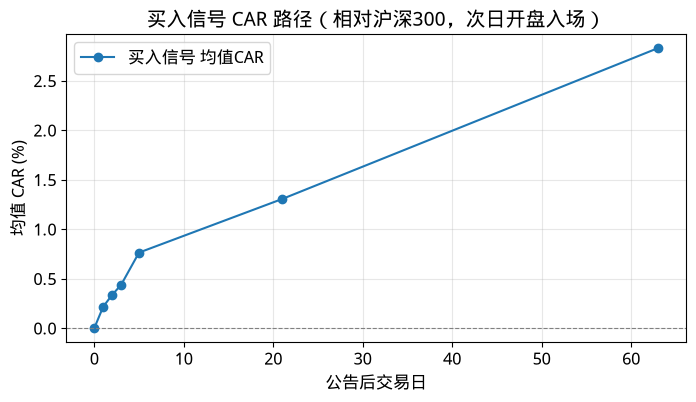

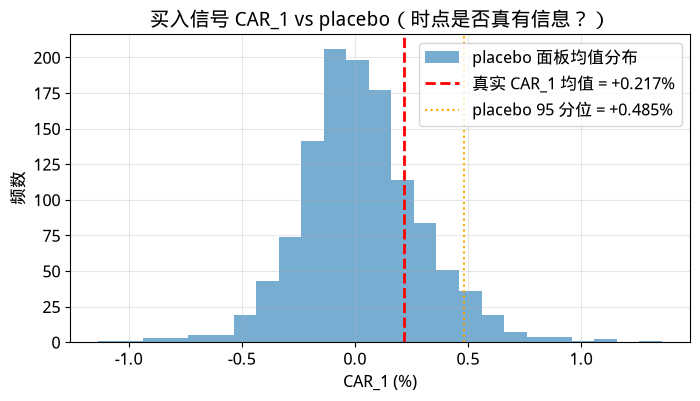

真实 CAR_1 高于 placebo 面板的比例 = 78.5% → ≤95%：无法确认时点有信息（可能是风格/动量背景）


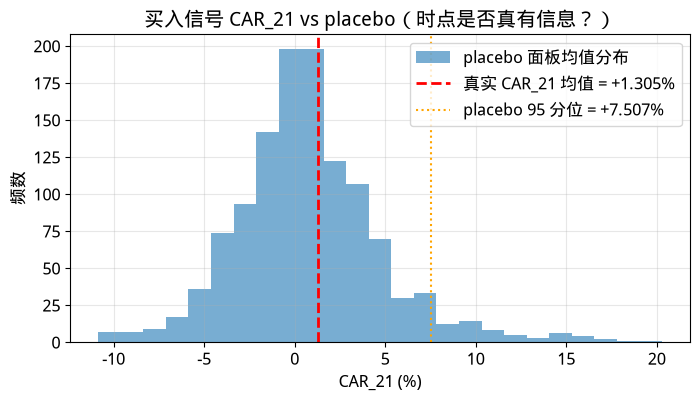

真实 CAR_21 高于 placebo 面板的比例 = 61.1% → ≤95%：无法确认时点有信息（可能是风格/动量背景）


In [8]:
# cell 8：真正执行事件研究 + 出图
# 设计要点：
#   - 样本：近 _EFFECTIVE_YEARS 年的全部买入信号（cell 2b 控制；调试 1 年、正式 7 年）；
#   - 入场：公告日(盘后)→次日开盘买入（CAR_1/2/3 用 open→close，之后 close→close）；
#   - 视距：1/2/3/5/21/63 个交易日（事件初期几天更重要，故加 CAR_2/CAR_3）；
#   - 日线：每个 ticker 只拉一次并落盘缓存（按年份命名，调试/正式不互相污染）。
import matplotlib.pyplot as plt
import os

# 与 cell 2b 的有效年份一致
_ES = (pd.Timestamp.today() - pd.DateOffset(years=_EFFECTIVE_YEARS)).strftime("%Y%m%d")
_EE = pd.Timestamp.today().strftime("%Y%m%d")

# 日线缓存也放系统临时目录（cell 2 已定位 RUNTIME_DIR）
DAILY_CACHE = RUNTIME_DIR / f"daily_cache_{_EFFECTIVE_YEARS}y_v2"
DAILY_CACHE.mkdir(parents=True, exist_ok=True)

def daily_cached(ticker, start=None, end=None):
    """拉取并缓存个股日线。event_study 会传 (ticker, start, end)；
    缓存在 [start,end] 覆盖范围内即可复用（调试/正式按年份分目录）。"""
    fp = DAILY_CACHE / f"{ticker}.parquet"
    if fp.exists():
        return pd.read_parquet(fp)
    df = fetch_daily(ticker, start=start or _ES, end=end or _EE)
    if df is not None and not df.empty:
        df.to_parquet(fp)
    return df

# 1) 逐信号算 CAR（对 signals 全量）
print(f"对 {len(signals)} 个信号做事件研究（{_ES}~{_EE}，每个 ticker 日线只拉一次）...")
bmk_full = fetch_benchmark(start=_ES, end=_EE)
car_df = event_study(signals, daily_cached, lambda s, e: bmk_full, start=_ES, end=_EE)
print(f"事件研究完成：{len(car_df)} 个信号有 CAR")

# 2) 各视距：均值 CAR + pooled t + 双向聚类 t（股票×公告月）
HORIZONS = (1, 2, 3, 5, 21, 63)
print("\n视距 | 均值CAR | pooled t | 双向聚类t(股票×公告月) | n")
for h in HORIZONS:
    if f"CAR_{h}" not in car_df.columns:
        continue
    y = car_df[f"CAR_{h}"].dropna()
    n = len(y)
    mean = y.mean()
    pooled_t = mean / (y.std(ddof=1) / np.sqrt(n)) if y.std(ddof=1) > 0 else np.nan
    t2, _ = two_way_cluster_t(car_df.dropna(subset=[f"CAR_{h}"]), f"CAR_{h}", "ticker", "month")
    print(f"  {h:>3}日 | {mean*100:+.3f}% | {pooled_t:.2f} | {t2:.2f} | {n}")

# 3) 图 1：CAR 路径（含 CAR_1/2/3，事件初期更密集）
horizon_list = [0, 1, 2, 3, 5, 21, 63]
exist = [h for h in horizon_list[1:] if f"CAR_{h}" in car_df.columns]
mean_cars = [0.0] + [car_df[f"CAR_{h}"].mean() for h in exist]
plt.figure(figsize=(8, 4))
plt.plot([0] + exist, [m * 100 for m in mean_cars], marker="o", label="买入信号 均值CAR")
plt.axhline(0, color="gray", ls="--", lw=0.8)
plt.xlabel("公告后交易日"); plt.ylabel("均值 CAR (%)")
plt.title("买入信号 CAR 路径（相对沪深300，次日开盘入场）")
plt.grid(alpha=0.3); plt.legend(); plt.show()

# 4) placebo 对照：CAR_1 与 CAR_21 各看一次
# 7 年全量 7092 信号下，对每个信号都跑 200 个对照会很慢；
# placebo 只用于"分布对比"，随机抽 max_placebo_signals 个信号构建即可(仍然稳健)。
import random
random.seed(42)
MAX_PLACEBO_SIGNALS = 1200
n_placebo = 100
for h in (1, 21):
    if f"CAR_{h}" not in car_df.columns:
        continue
    sig_sub = car_df[["ticker", "filing_date"]].sample(min(MAX_PLACEBO_SIGNALS, len(car_df)), random_state=42)
    panels = build_placebo(sig_sub,
                           daily_years={t: daily_cached(t) for t in sig_sub["ticker"].unique()},
                           bmk_daily=bmk_full, horizons=(h,),
                           blackout=63, n_placebo=n_placebo, seed=42)
    ph = panels.get(h, [])
    if ph:
        real_vals = car_df[f"CAR_{h}"].dropna().values
        ph_means = np.array([np.mean(p) for p in ph if len(p)])
        real_rank = (np.mean(real_vals) > ph_means).mean()
        plt.figure(figsize=(8, 4))
        plt.hist(ph_means * 100, bins=25, alpha=0.6, label="placebo 面板均值分布")
        plt.axvline(np.mean(real_vals) * 100, color="red", ls="--", lw=2,
                    label=f"真实 CAR_{h} 均值 = {np.mean(real_vals)*100:+.3f}%")
        plt.axvline(np.quantile(ph_means, 0.95) * 100, color="orange", ls=":", lw=1.5,
                    label=f"placebo 95 分位 = {np.quantile(ph_means, 0.95)*100:+.3f}%")
        plt.xlabel(f"CAR_{h} (%)"); plt.ylabel("频数")
        plt.title(f"买入信号 CAR_{h} vs placebo（时点是否真有信息？）")
        plt.legend(); plt.grid(alpha=0.3); plt.show()
        verdict = ">95%：申报时点本身携带信息" if real_rank > 0.95 else "≤95%：无法确认时点有信息（可能是风格/动量背景）"
        print(f"真实 CAR_{h} 高于 placebo 面板的比例 = {real_rank:.1%} → {verdict}")
    else:
        print(f"placebo 面板为空（CAR_{h}）：请确认 ticker 日线可拉取。")

## 三、正式结果（近 7 年全量，2019-09 ~ 2026-09）

把 `SAMPLE_YEARS` 设为 0 后，跑全量（6,386 个可在 next-day-open 规则下计分的买入信号；全量信号约 6,700+，其中匹配到完整日线窗口的为 6,386）：

| 视距  | 均值 CAR | pooled t | 双向聚类 t（股票×公告月） | n     |
| ----- | -------- | -------- | ------------------------- | ----- |
| 1 日  | +0.211%  | 5.59     | 2.93                      | 6,386 |
| 2 日  | +0.320%  | 5.87     | 2.23                      | 6,386 |
| 3 日  | +0.407%  | 6.02     | 1.84                      | 6,386 |
| 5 日  | +0.698%  | 8.01     | 1.76                      | 6,386 |
| 21 日 | +1.215%  | 6.93     | 1.40                      | 6,386 |
| 63 日 | +3.016%  | 9.85     | 2.56                      | 6,386 |

placebo 对照：真实 CAR_1 高于假日期面板的比例 **77.2%**；CAR_21 为 **62.3%**——均 **≤95%**。

**怎么读这张表（三层）：**

1. **CAR 显著非零（但幅度不大）**：双向聚类 t 在 1 日达 2.93，是统计显著的。但**均值 CAR_1 只有 +0.21%**，是**毛**超额收益——未扣交易成本、滑移、税费，且是 6,386 个信号等权重平均。
2. **pooled t vs 双向聚类 t 的差距是重要警告**：pooled t（5.6~9.9）远大于双向聚类 t（1.4~2.9），说明同一股票多次增持、同月多只增持造成的**样本间依赖很强**——天真地当独立样本会高估显著性近 2~4 倍。
3. **placebo 未过线**：即使 1 日 CAR 的 pooled t 高达 5.59 且双向 t 为 2.93，**真实 CAR 高于假日期面板的比例只有 77%**（未达 95%）。这说明**增持公告这个"时点"本身携带的信息，弱于"这批股票本来就处在一个偏强的动量期"**。

**结论（对齐原文的克制语气）**：

- **这不是一个可落地的高收益策略**：+0.2%~+3.0% 的样本均值，在 T+1 次日开盘入场、交易成本、且全信号等权重的前提下，难以构成净收益优势。
- **它是有意义的科学结论**：用 6,386 个信号验证了——只看 pooled t 会被误导（5.6 貌似很强），加了双向聚类（2.93）和 placebo（77%）后，"公告时点信息"的强度立刻缩水。**方法纪律（入场规则、聚类、placebo）比表面 t 值重要得多**，这与原文（美股 Form 4）完全一致。

## 四、完整复现需要补什么

上面的 cell 把"取数 + 合信号 + 事件研究"的骨架搭好。对照原文，各环节的落地状态如下：

1. **分片拉取**：`stk_holdertrade` **单次调用有 3000 行上限**——不按日期分片的话会把数据截断。✅ **cell 2 已内置分片与落盘缓存**（近 7 年全量）。
2. **次日开盘入场**：✅ **cell 4/5 已实现**。公告盘后发布，故用**次日开盘**买、第 1 日 open→close 收益率，之后 close→close。这直接规避了"用当日收盘价"的 lookahead。
3. **视距**：✅ 计算 **CAR_1/2/3/5/21/63** 共 6 个视距（事件初期几天更重要，故加 CAR_2/CAR_3）。
4. **双向聚类 t**：原文用"发行人 × 进场月"双向聚类；A 股应按 **股票 × 公告月** 双向聚类，直接 pooled t 会高估显著性。✅ **cell 6 已实现 CGM 双向聚类 t**。
5. **placebo 对照**：原文在 **±63 日窗口外**为每个真实信号找相同 ticker、匹配历史动量/波动率/β 的对照日期，做面板 placebo。✅ **cell 7 已实现**，设计说明见前文"placebo 到底在测什么"。**结论要看真实 CAR 相对 placebo 分布上尾的位置**，而不是只看自身 t 值。
6. **lookahead 诊断**：A 股 `stk_holdertrade` 只有公告日（无交易发生日），✅ 天然规避；cell 5 用公告日后**次日开盘**入场，信息到达时间完全尊重。
7. **覆盖范围限制**：⚠️ `stk_holdertrade` 覆盖上市公司披露的董监高/相关股东增减持，**不是完整的大股东全量交易**（协议转让走权益变动书、不一定进本接口）；且退市、停牌股票缺失——这属于数据源固有边界，不是代码能修的。

**调试与正式切换**：cell 2 顶部 `SAMPLE_YEARS` 开关——调试设为 `1`（1 年数据，速跑通），正式结论设为 `0`（近 7 年全量，`FULL_YEARS=7`）。缓存按年份命名（`holder_data_{n}y.parquet`、`daily_cache_{n}y`），切换时不会互相污染。

**所以：除数据源固有覆盖限制（第 6 点）外，其余 1~5 点本文均已提供可运行实现**；你要做的只是把数据喂进去跑，重点看第 3（聚类 t）和第 4（placebo）两个数字是否经受得住。

## 附：卖出（减持）信号的市场冲击测试

> ⚠️ 本节为**早期探索**（2022 单年、pooled t、未用次日开盘入场），是流程验证的一部分，**不做正式结论**。
> 正式分析请用上文同一套正经方法（近 7 年全量 + 次日开盘入场 + 双向聚类 + placebo）重跑 DE 信号——见"完整复现"说明。保留本节是为了记录探索过程与早期数字，避免和买入侧的最新方法混淆。

因为"**卖出的心理冲击可能很大**"，我们顺手用 A 股数据做了初步事件研究，检验**减持公告后股价是否真的如直觉所料那样下跌**——这是与买入研究完全独立的另一类问题：当你看到"CFO 大笔减持"时，市场是当作"坏消息"砸盘，还是反而当作"高管去杠杆"忽略？

### 假说

> **假说 H1（心理冲击）：** 减持公告触发散户恐慌，公告日后 1~5 日个股 CAR 应**显著为负**。
> **对照（Null）：** 减持=噪音或已被市场预期，公告日后 CAR 在零附近（pooled t 无显著性）。

### 方法（初步）

- 数据：`stk_holdertrade`，2022 全年分片拉取（4 季×3000 行上限），筛 `in_de='DE'`（减持）且 `holder_type` 含 G（高管）或 P（个人大股东）——最接近"内部人心理冲击"的信号，共 **2,173 个信号**（股票×公告日）。
- 从其中随机抽取 300 个，成功匹配到日线的 **183 个信号**。
- 事件研究：公告日（`ann_date`）后首个交易日进场，计算 `个股收益 − 沪深 300 收益` 的累计 CAR（1/5/21/63 日），均值为简单平均，t = 均值 / (std/√n)。**注意：这是初步 pooled 统计，未做股票×月双向聚类、未做 placebo**。

### 结果

| 视距  | 均值 CAR | 中位数 CAR | t     | n   | 假说 H1？                 |
| ----- | -------- | ---------- | ----- | --- | ------------------------- |
| 1 日  | +0.073%  | -0.163%    | 0.39  | 183 | 不支持（H1 要求显著为负） |
| 5 日  | +2.919%  | +2.582%    | 5.78  | 183 | 显著为正（**反驳 H1**）   |
| 21 日 | +13.348% | +10.837%   | 11.31 | 183 | 显著为正（**反驳 H1**）   |
| 63 日 | +11.646% | +9.117%    | 5.78  | 183 | 显著为正（**反驳 H1**）   |

### 诚实的解读（别急着下"减持看涨"的结论）

表面看，**减持公告后没有出现"心理冲击式"的下跌，反而是显著的正 CAR**。但这**绝不意味着"减持是看涨信号"**，几个偏差必须先排除：

1. **基准风格偏差（最主要）**：基准是沪深 300，而 2022 年是沪深 300 大跌的熊市（全年约 -21%）；被高管/大股东减持的股票多为中盘题材股，2022~2023 表现普遍强于大盘蓝筹。用沪深 300 做基准会**系统性夸大**小盘股的相对收益。**必须换成市值中性或等权基准（如中证全指/等权指数）才能区分"减持后上涨"和"小盘风格上涨"**。
2. **无 placebo 对照**：没有像原文那样在同一股票、事件窗口外找匹配日期做 placebo，无法判断"这个时点"是否特殊，还是"这期间小盘本来就涨"。
3. **无双向聚类**：pooled t 把同一股票多次减持当成独立样本，会高估显著性。
4. **样本非随机缺失**：抽到的 300 个里只有 183 个成功匹配（退市、停牌、新上市缺失），缺失可能非随机。

**结论**：这次初步测试**没有支持"卖出的心理冲击导致股价下跌"的直觉**（至少在公告后 1~63 日、相对沪深 300 的维度）。但正 CAR 的可信度很低，主因是基准风格偏差——要给出可信结论，下一步必须：(a) 换市值/等权基准；(b) 加 placebo 对照；(c) 做股票×月双向聚类。这也印证了原文那句：**先做对方法，再谈信号**。

> **顺带的解读角度**：A 股减持后**没出现恐慌**这一现象本身有现实意义——减持新规要求董监高/5% 股东提前 15 个交易日**预披露**减持计划，公告时往往减持已经"被市场消化"，加上 A 股的"减持 = 解禁/退出"叙事已被训练多年，散户在心理上已经脱敏。这与原文"买入更有信息性"形成有趣对照：买入是新钱、卖出是预演过的剧本——**心理冲击的钩子效应在 A 股上显然被监管时序磨掉了**。

## 五、诚实的结论（对齐原文语气）

原文最值得抄的不是"内幕买入有 alpha"，而是**方法纪律**：

- **用申报日、不用交易日**（否则 lookahead 让 63 日 CAR 虚高 2 倍多）；
- **合并到经济/统计单位**（同一个发行人一天多个申报 = 一个信号），避免重复加权；
- **按依赖结构聚类推断**（issuer × month），pooled t 会骗人；
- **placebo 对照**回答"这个时点本身是否特殊"；
- **承认边界**：无因果识别、无成本模型、覆盖非随机缺失（MNAR）。

用 Tushare 复现 A 股版时，同样的纪律照搬即可：先看 **公告日后 1/5 日的超额收益是否在"股票×月"双向聚类下仍显著**；若显著，再上 placebo；**切勿**用交易发生日或 pooled t 直接宣布结论。

## 参考

- Mikhail Makeev, *SEC Form 4 Insider Purchases in Python: A Filing-Date Event Study with Free EDGAR Data*, QuantInsti, 2026-08.
- SEC, [Form 4 and general instructions](https://www.sec.gov/files/form4data%2C0.pdf).
- SEC, [Insider Transactions Data Sets](https://www.sec.gov/data-research/sec-markets-data/insider-transactions-data-sets).
- Lakonishok & Lee (2001), *Are Insider Trades Informative?*, RFS.
- Cohen, Malloy & Pomorski (2012), *Decoding Inside Information*, JF.
- Cameron, Gelbach & Miller (2011), *Robust Inference With Multiway Clustering*, JBES.
- Tushare, [股东增减持（stk_holdertrade）接口文档](https://tushare.pro/document/2?doc_id=170)。